In [1]:
# Синхронизация с Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


ШАГ 0: Импорт библиотек и распаковка данных

ШАГ 0.5: Распаковка и упрощение структуры данных

In [2]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from scipy.ndimage import minimum_filter1d
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm

# Настройки визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ПУТЬ К АРХИВУ
ARCHIVE_PATH = '/content/drive/MyDrive/dataset.zip'
BASE_PATH = '/content/'
# После распаковки папки control/, endo/, exo/ будут по адресу BASE_PATH

# Если еще не распакован - распаковка архива
if not os.path.exists(os.path.join(BASE_PATH, 'control')):
    print("Распаковка датасета...")
    !unzip -o "$ARCHIVE_PATH" -d "$BASE_PATH"
    print("Распаковка завершена!")
else:
    print("Датасет уже распакован")


def simplify_dataset_structure(base_path, class_names=['control', 'endo', 'exo']):
    """
    Перемещает все .txt файлы из подпапок напрямую в папки классов.
    Пример: control/mk1/file.txt → control/mk1_file.txt

    Итоговая структура:
    /content/
    ├── control/     # все .txt файлы здесь
    ├── endo/        # все .txt файлы здесь
    └── exo/         # все .txt файлы здесь
    """
    for class_name in class_names:
        class_path = os.path.join(base_path, class_name)

        if not os.path.exists(class_path):
            print(f"Папка {class_path} не найдена, пропускаем")
            continue

        print(f"\nОбработка {class_name}...")

        # Получаем все подпапки
        subfolders = [d for d in os.listdir(class_path)
                     if os.path.isdir(os.path.join(class_path, d))]

        files_moved = 0

        for subfolder in subfolders:
            subfolder_path = os.path.join(class_path, subfolder)

            for filename in os.listdir(subfolder_path):
                if filename.endswith('.txt'):
                    src = os.path.join(subfolder_path, filename)

                    # Добавляем префикс подпапки (на всякий случай, - избежать конфликтов имен)
                    new_filename = f"{subfolder}_{filename}"
                    dst = os.path.join(class_path, new_filename)

                    shutil.move(src, dst)
                    files_moved += 1

            # shutil.rmtree (вместо os.rmdir)
            # чтобы удалять подпапки даже если в них остались не-.txt файлы
            shutil.rmtree(subfolder_path)
            print(f"Удалена подпапка: {subfolder}")

        print(f"{class_name}: перемещено {files_moved} файлов")

    print("\nСтруктура данных упрощена!")


# Упрощаем структуру (выполняется один раз!)
print("\nУпрощение структуры данных...")
simplify_dataset_structure(BASE_PATH)

# Проверка результата
print("\nПроверка структуры:")
for class_name in ['control', 'endo', 'exo']:
    class_path = os.path.join(BASE_PATH, class_name)
    if os.path.exists(class_path):
        n_files = len([f for f in os.listdir(class_path) if f.endswith('.txt')])
        print(f"  {class_name}/: {n_files} файлов")

Распаковка датасета...
Archive:  /content/drive/MyDrive/dataset.zip
   creating: /content/endo/
   creating: /content/endo/mend1/
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place1_1.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place1_2.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place2_1.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place2_2.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place3_1.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place3_2.txt  
  inflating: /content/endo/mend1/cortex_endo_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place1_1.txt  
  inflati

ШАГ 1: Загрузка данных и парсинг метаданных

In [3]:
KNOWN_REGIONS = ['cortex', 'striatum', 'cerebellum']

def parse_filename(filepath):
    """
    Извлекает регион мозга из имени файла.
    Ищет первый токен из списка известных регионов среди всех частей имени.
    Пример: mend2a_cortex_left_endo_...txt → brain_region='cortex'
    Пример: mk1_cortex_control_...txt    → brain_region='cortex'
    """
    filename = os.path.basename(filepath)
    name_parts = filename.replace('.txt', '').split('_')

    # ИСПРАВЛЕНО: ищем первый подходящий токен среди всех частей имени,
    # а не только среди первого — чтобы корректно обрабатывать endo/exo файлы
    # (у них имя начинается с mend2a_, mexo1_ и т.д.)
    brain_region = next((p for p in name_parts if p in KNOWN_REGIONS), 'unknown')

    return {
        'filepath': filepath,
        'filename': filename,
        'brain_region': brain_region,
    }


def load_spectrum(filepath):
    """
    Загружает спектр из .txt файла.
    Формат: X Y Wave Intensity (4 столбца).
    engine='c' вместо engine='python' для ускорения.
    """
    data = pd.read_csv(filepath, sep=r'\s+', comment='#', header=None,
                      names=['X', 'Y', 'Wave', 'Intensity'], engine='c')

    # Очистка от NaN/Inf
    data = data.dropna(subset=['Wave', 'Intensity'])
    data = data[np.isfinite(data['Wave']) & np.isfinite(data['Intensity'])]

    # Сортировка по волновому числу
    data = data.sort_values('Wave').reset_index(drop=True)

    return data['Wave'].values, data['Intensity'].values


def load_all_data(base_path):
    """
    Загружает все спектры напрямую из папок control/, endo/, exo/.
    """
    all_data = []

    class_mapping = {
        'control': 0,
        'endo': 1,
        'exo': 2
    }

    for class_name, class_label in tqdm(class_mapping.items(), desc="Загрузка классов"):
        class_path = os.path.join(base_path, class_name)

        if not os.path.exists(class_path):
            print(f"Папка {class_path} не найдена")
            continue

        txt_files = glob.glob(os.path.join(class_path, '*.txt'))

        txt_files = [f for f in txt_files if 'Average' not in f]

        print(f"{class_name}: найдено {len(txt_files)} файлов")

        for filepath in txt_files:
            # ИСПРАВЛЕНО: убран отладочный print для каждого файла — он сильно замедлял вывод
            try:
                wave, intensity = load_spectrum(filepath)
                meta = parse_filename(filepath)

                record = {
                    'spectrum_id': os.path.basename(filepath),
                    'wave': wave,
                    'intensity': intensity,
                    'n_points': len(wave),
                    'target': class_label,
                    'group_type': class_name,
                    **meta
                }
                all_data.append(record)

            except Exception as e:
                print(f"Ошибка {filepath}: {e}")
                continue

    print(f"\nВсего загружено спектров: {len(all_data)}")
    return all_data


# Загрузка
print("\nЗагрузка данных...")
raw_data = load_all_data(BASE_PATH)


Загрузка данных...


Загрузка классов:   0%|          | 0/3 [00:00<?, ?it/s]

control: найдено 80 файлов


Загрузка классов:  33%|███▎      | 1/3 [00:47<01:35, 47.99s/it]

endo: найдено 73 файлов


Загрузка классов:  67%|██████▋   | 2/3 [01:33<00:46, 46.65s/it]

exo: найдено 84 файлов


Загрузка классов: 100%|██████████| 3/3 [02:23<00:00, 47.92s/it]


Всего загружено спектров: 237


ШАГ 2: Предобработка спектров (preproccessing)

In [4]:
def preprocess_spectrum(wave, intensity,
                       baseline_window=100,
                       savgol_window=15,
                       savgol_polyorder=3,
                       normalization='minmax'
                       ):
    """
    Тут полный пайплайн предобработки спектра.
    """
    intensity = intensity.copy()

    # === 1. Коррекция базовой линии ===
    if baseline_window > 0 and len(intensity) > baseline_window:
        baseline = minimum_filter1d(intensity, size=baseline_window)
        baseline = savgol_filter(baseline, savgol_window, savgol_polyorder)
        intensity = intensity - baseline
        intensity = np.clip(intensity, 0, None)

    # === 2. Сглаживание Савицкого-Голея ===
    if savgol_window > 0 and len(intensity) >= savgol_window:
        win = savgol_window if savgol_window % 2 == 1 else savgol_window - 1
        win = min(win, len(intensity) - 1 if len(intensity) % 2 == 0 else len(intensity))
        if win >= savgol_polyorder + 2:
            intensity = savgol_filter(intensity, win, savgol_polyorder)

    # === 3. Нормализация ===
    if normalization == 'minmax':
        min_val, max_val = intensity.min(), intensity.max()
        if max_val > min_val:
            intensity = (intensity - min_val) / (max_val - min_val)
        else:
            intensity = np.zeros_like(intensity)

    elif normalization == 'area':
        auc = np.trapz(intensity, wave)
        if auc > 0:
            intensity = intensity / auc

    return intensity


def create_feature_matrix(data_list, wave_grid=None, preprocess=True):
    """
    Создаёт матрицу признаков.
    """
    if wave_grid is None:
        wave_grid = data_list[0]['wave']

    features = []
    metadata = []

    for record in tqdm(data_list, desc="Создание матрицы признаков"):
        wave, intensity = record['wave'], record['intensity']

        if preprocess:
            intensity = preprocess_spectrum(wave, intensity)

        if not np.array_equal(wave, wave_grid):
            intensity = np.interp(wave_grid, wave, intensity)

        features.append(intensity)

        meta_row = {k: v for k, v in record.items() if k not in ['wave', 'intensity', 'spectrum_id']}
        meta_row['spectrum_id'] = record['spectrum_id']
        metadata.append(meta_row)

    X = np.array(features)
    meta_df = pd.DataFrame(metadata)

    print(f"Матрица признаков: {X.shape}")
    return X, meta_df, wave_grid


# Создание матрицы
print("\nСоздание feature matrix...")
X, meta_df, wave_grid = create_feature_matrix(raw_data, preprocess=True)

# Целевая переменная
y = np.array([d['target'] for d in raw_data])

# Финальный DataFrame
df_final = meta_df.copy()
df_final['target'] = y
df_final['target_name'] = df_final['target'].map({0: 'control', 1: 'endo', 2: 'exo'})

print("\nСтатистика по классам:")
print(df_final['target_name'].value_counts())


Создание feature matrix...


Создание матрицы признаков: 100%|██████████| 237/237 [00:09<00:00, 24.80it/s]


Матрица признаков: (237, 532875)

Статистика по классам:
target_name
exo        84
control    80
endo       73
Name: count, dtype: int64


ШАГ 3: Обучение модели

Train: (189, 532875), Test: (48, 532875)

🌲🌲🌲🌲🌲🌲Random Forest🌴🌴🌴🌴🌴...
Accuracy: 0.3542

Classification Report:
              precision    recall  f1-score   support

     control       0.40      0.38      0.39        16
        endo       0.33      0.27      0.30        15
         exo       0.33      0.41      0.37        17

    accuracy                           0.35        48
   macro avg       0.36      0.35      0.35        48
weighted avg       0.36      0.35      0.35        48



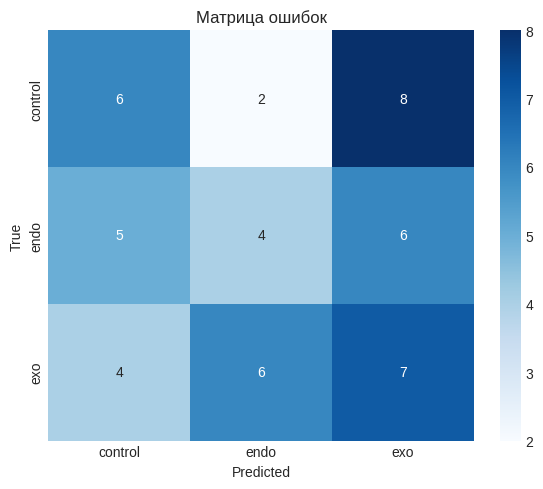

In [5]:
# Разделение выборок
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Random Forest - алгоритм ML
print("\n🌲🌲🌲🌲🌲🌲Random Forest🌴🌴🌴🌴🌴...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['control', 'endo', 'exo']))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['control', 'endo', 'exo'],
            yticklabels=['control', 'endo', 'exo'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()